In [3]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.path.join(os.getcwd(), ".."), ".."))
sys.path.append(parent_dir)
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
from data_generation.models.tech_substitution import TechnologySubstitution
from data_generation.models.tech_substitution import TechSubNumericalSolver
from data_generation.models.general_ode_solver import FitzHughNagumoModel
from data_generation.models.general_ode_solver import GeneralODENumericalSolver
from data_generation.simulations.grid import Grid, tangent_transformation
from data_generation.simulations.simulator import Simulator

In [4]:
bounds = [(0, np.inf), (0, np.inf)]
resolution = [20, 20]
transformations = [tangent_transformation(3, 0.5), tangent_transformation(3, 0.5)]

tech = TechnologySubstitution()
solver = TechSubNumericalSolver(tech)
grid = Grid(bounds, resolution, transformations)

sim = Simulator(grid,tech,solver)

controls = np.array([0.5, 1])

In [33]:
alpha=0.5
method='angular'

importance = sim.calculate_importance_measure(controls,method=method,alpha=alpha, debug=True)

Average angle above diagonal (x2 > x1): 0.04337875458936359
Average angle below diagonal (x2 < x1): 0.3250355020020203
Cell with max angular difference: (17, 16), value: 1.2208316107246135
Located at coordinates: [75.82242711 37.71665779]
This cell is below diagonal


In [34]:
samples_per_cell = sim.importance_to_samples(importance, 20000, min_samples_per_cell=20)

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Cell Importance Measure'}, xlabel='x1', ylabel='x2'>)

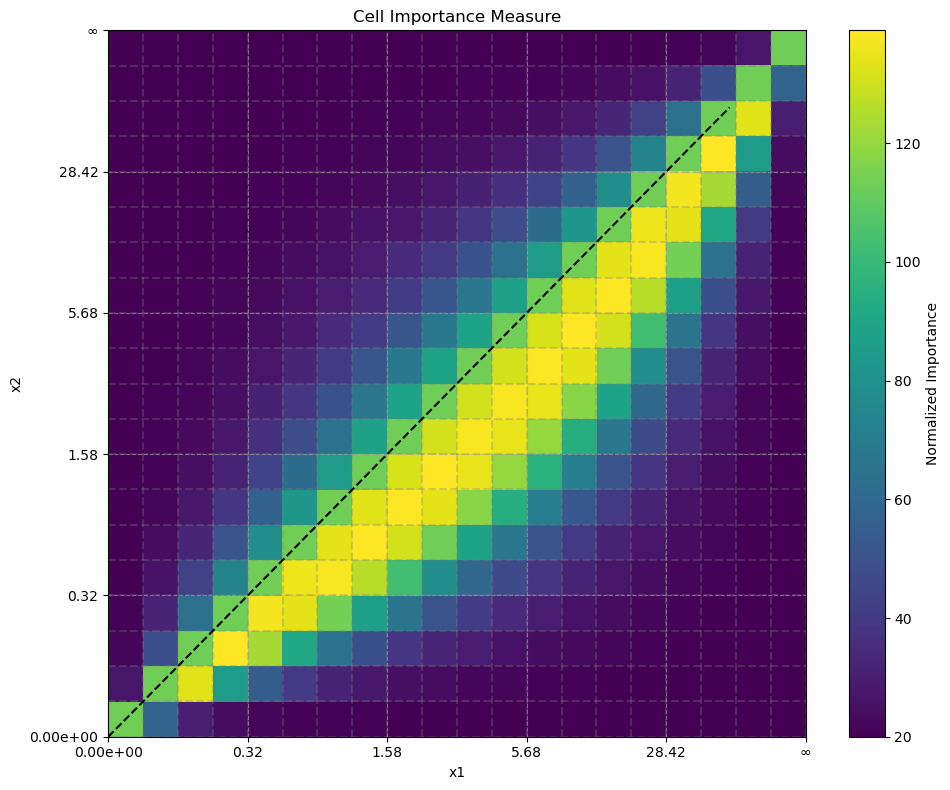

In [35]:
sim.visualize_importance_measure(samples_per_cell)

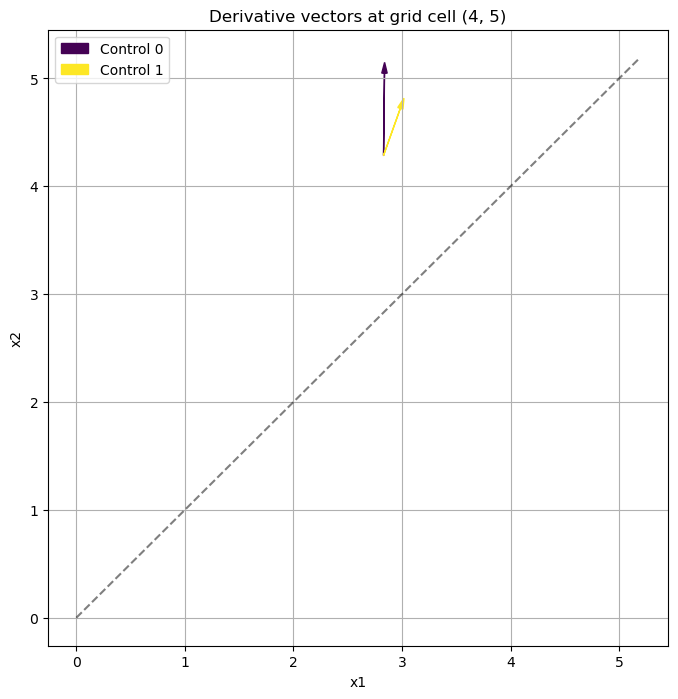

In [6]:
control_values = np.array([[0.5], [1.0]])  

# Choose a grid cell to examine (using the grid indices, not coordinates)
grid_idx = (4, 5)  

# 3. Call the function
fig = sim.visualize_derivatives_at_cell(grid_idx, control_values)
plt.show()

# 4. Save the figure if needed
# fig.savefig(f'derivatives_at_cell_{grid_idx[0]}_{grid_idx[1]}.png')